In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial.transform import Rotation as R

In [3]:
nx = 4 # number of grid points in x and y directions

In [4]:
def plot_arrow_3d(
    ax,
    start=[0, 0, 0],
    end=[1, 0, 0],
    head_length=0.2,
    head_width=0.1,
    color="r",
    alpha=0.7,
    zorder=10,
):
    """
    Plot a 3D arrow on the given axes.
    """
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)

    vec = end - start
    length = np.linalg.norm(vec)
    if length == 0:
        return

    direction = vec / length
    tail_end = end - direction * head_length

    # --- compute view direction ---
    elev = np.deg2rad(ax.elev)
    azim = np.deg2rad(ax.azim)
    view_dir = np.array(
        [np.cos(elev) * np.cos(azim), np.cos(elev) * np.sin(azim), np.sin(elev)]
    )
    view_dir = view_dir / np.linalg.norm(view_dir)
    # positive means arrow points toward camera
    facing_camera = np.dot(direction, view_dir) > 0

    # Plot shaft — behind head if arrow faces camera, in front if away
    shaft_z = zorder - 1 if facing_camera else zorder + 2
    ax.plot3D(
        [start[0], tail_end[0]],
        [start[1], tail_end[1]],
        [start[2], tail_end[2]],
        color=color,
        linewidth=2,
        zorder=shaft_z,
        alpha=alpha,
    )

    # --- build cone lateral surface ---
    u, v = np.mgrid[0 : 2 * np.pi : 30j, 0:1:20j]
    x_cone = head_width * v * np.cos(u)
    y_cone = head_width * v * np.sin(u)
    z_cone = head_length * (1 - v)  # tip at z=head_length, base at z=0
    cone_pts = np.dstack((x_cone, y_cone, z_cone))

    # --- build cone base disk ---
    u_disk = np.linspace(0, 2 * np.pi, 30)
    x_disk = head_width * np.cos(u_disk)
    y_disk = head_width * np.sin(u_disk)
    z_disk = np.zeros_like(u_disk)
    # single filled polygon for the base
    base_face = np.stack([x_disk, y_disk, z_disk], axis=1)

    # --- rotate both to align with direction ---
    default_dir = np.array([0, 0, 1])
    axis = np.cross(default_dir, direction)
    if np.linalg.norm(axis) > 1e-6:
        angle = np.arccos(np.clip(np.dot(default_dir, direction), -1, 1))
        rot = R.from_rotvec(axis / np.linalg.norm(axis) * angle)
        mat = rot.as_matrix()
        cone_pts = np.dot(cone_pts, mat.T)
        base_face = np.dot(base_face, mat.T)
    elif np.dot(default_dir, direction) < 0:
        cone_pts[:, :, 2] *= -1
        base_face[:, 2] *= -1

    cone_pts = cone_pts + tail_end
    base_face = base_face + tail_end

    # --- sort cone lateral faces back-to-front ---
    M = ax.get_proj()
    faces = []
    depths = []
    ni, nj = cone_pts.shape[:2]
    for i in range(ni - 1):
        for j in range(nj - 1):
            face = [
                cone_pts[i, j],
                cone_pts[i, j + 1],
                cone_pts[i + 1, j + 1],
                cone_pts[i + 1, j],
            ]
            faces.append(face)
            xs, ys, zs = zip(*face)
            _, _, zproj = proj3d.proj_transform(xs, ys, zs, M)
            depths.append(np.mean(zproj))

    order = np.argsort(depths)
    faces = [faces[idx] for idx in order]

    # --- depth of base disk ---
    xs, ys, zs = base_face[:, 0], base_face[:, 1], base_face[:, 2]
    _, _, zproj_base = proj3d.proj_transform(xs, ys, zs, M)
    base_depth = np.mean(zproj_base)
    cone_median_depth = np.median(depths)

    # if arrow faces camera: base is closer → draw cone first, then base
    # if arrow faces away:   base is farther → draw base first, then cone
    base_in_front = facing_camera

    if base_in_front:
        base_col = Poly3DCollection(
            [base_face], facecolor=color, edgecolor="none", alpha=alpha, zorder=zorder
        )
        cone_col = Poly3DCollection(
            faces, facecolor=color, edgecolor="none", alpha=alpha, zorder=zorder + 1
        )
        ax.add_collection3d(cone_col)
        ax.add_collection3d(base_col)
    else:
        base_col = Poly3DCollection(
            [base_face],
            facecolor=color,
            edgecolor="none",
            alpha=alpha,
            zorder=zorder + 1,
        )
        cone_col = Poly3DCollection(
            faces, facecolor=color, edgecolor="none", alpha=alpha, zorder=zorder
        )
        ax.add_collection3d(base_col)
        ax.add_collection3d(cone_col)

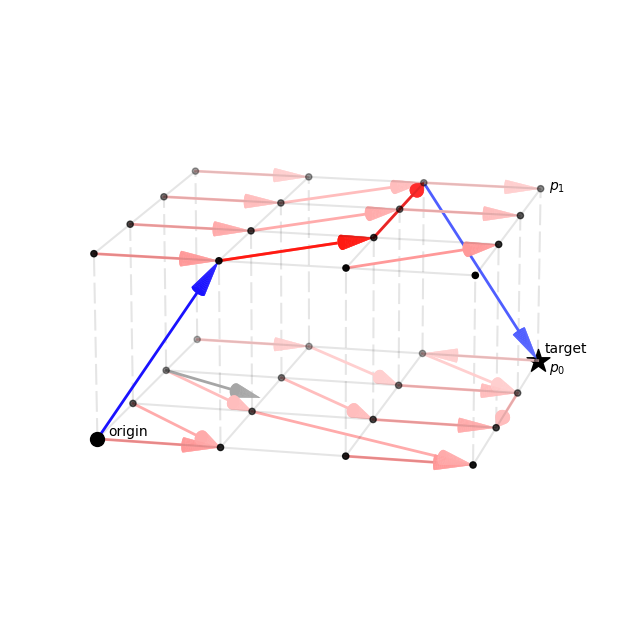

In [14]:
# 3d plot showing a 3d grid

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 8))
# ax.set_proj_type('ortho')

x = np.linspace(0, 10, nx)
y = np.linspace(0, 10, nx)
z = np.linspace(0, 5, 2)
x, y, z = np.meshgrid(x, y, z)
ax.scatter(x, y, z, color="k",zorder=5)

# hide axes
ax.set_axis_off()

ax.set_zticks([0, 1])
ax.set_zticklabels(["0", "1"])
ax.set_zlabel("p_lev")

# add a 3d grid that connects all points
for i in range(z.shape[2]):
    ax.plot_wireframe(x[:, :, i], y[:, :, i], z[:, :, i], color="k", alpha=0.1, zorder=0)

# vertical lines connecting the two levels
for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        ax.plot([x[i, j, 0], x[i, j, 1]], [y[i, j, 0], y[i, j, 1]], [z[i, j, 0], z[i, j, 1]], 'k', alpha=0.1, zorder=0,linestyle=(0, (10, 3)))

# add vertical arrow to the left of the plot with label "pressure"
# ax.quiver(-0.5, 0, 1, 0, 0, -1, color="k")
# offset = 1.05
# plot_arrow_3d(
#     ax, start=[x[0,-1,0]*offset, y[-1,0,0]*offset, z[0, 0, 1]], end=[x[0,-1,0]*offset, y[-1,0,0]*offset, z[0, 0, 0]], color="k", head_length=1, head_width=0.2
# )
# ax.text(x[0,-1,0]*offset, y[-1,0,0]*offset, (z[0, 0, 1]-z[0, 0, 0])/2, "pressure", zdir=(0,0,-1), verticalalignment="center")


# setup transition matrix
tm = np.zeros(x.shape).astype(object)
tm[:] = None
tm [0, 0, 0] = (0, 1)
tm [1, 0, 0] = (0, 1)
tm [2, 0, 0] = (1, 1)
tm [3, 0, 0] = (3, 1)

# tm [0, 1, 0] = (-1, 2)
tm [1, 1, 0] = (0, 3)
tm [2, 1, 0] = (1, 2)
tm [3, 1, 0] = (2, 2)

tm [0, 2, 0] = (0, 3)
tm [1, 2, 0] = (1, 3)
tm [2, 2, 0] = (2, 3)
tm [3, 2, 0] = (2, 3)

# tm [0, 3, 0] = (0, 1)
# tm [1, 3, 0] = (0, 1)
tm [2, 3, 0] = (1, 3)
tm [3, 3, 0] = (3, 2)

tm [0, 0, 1] = (0, 1)
tm [1, 0, 1] = (1, 1)
tm [2, 0, 1] = (2, 1)
tm [3, 0, 1] = (3, 1)

tm [0, 1, 1] = (1, 2)
tm [1, 1, 1] = (2, 2)
tm [2, 1, 1] = (3, 2)
# tm [3, 1, 1] = (3, 2)

tm [0, 2, 1] = (1, 3)
tm [1, 2, 1] = (3, 2)
tm [2, 2, 1] = (2, 3)
tm [3, 2, 1] = (3, 3)


# plot arrows of the transition matrix
for k in range(tm.shape[2]):
    for i in range(tm.shape[1]):
        for j in range(tm.shape[0]):
            if tm[i, j, k] is not None:
                color = (1, 0.6+i*0.07, 0.6+i*0.07) # lighter color for vectors further away from camera
                plot_arrow_3d(
                    ax,
                    start=[x[i, j, k], y[i, j, k], z[i, j, k]],
                    end=[x[tm[i, j,k][0], tm[i, j,k][1], k], y[tm[i, j,k][0], tm[i, j,k][1], k], z[tm[i, j,k][0], tm[i, j,k][1], k]],
                    color=color,
                    head_length=1,
                    head_width=0.2,
                    alpha=1,
                )


# add example arrow of unrounded advection vector
plot_arrow_3d(
    ax,
    start=[x[2, 0, 0], y[2, 0, 0], z[2, 0, 0]],
    end=[x[1, 1, 0]-0.1, y[1, 1, 0]+1.3, z[1, 1, 0]],
    color=(0.65, 0.65, 0.65),
    head_length=1,
    head_width=0.2,
    alpha=1
)

route = [(0, 0, 0), (0, 1, 1), (0, 1, 1), (1, 2, 1), (3, 2, 1), (3, 3, 0)]

# origin and target points
ax.scatter(x[*route[0]], y[*route[0]], z[*route[0]], color="k", s=100, marker="o",zorder=20)
ax.scatter(x[*route[-1]], y[*route[-1]], z[*route[-1]], color="k", s=300, marker="*",zorder=20)
ax.text(x[*route[0]]+0.3, y[*route[0]], z[*route[0]]+0.1, "origin", color="k", horizontalalignment="left")
ax.text(x[*route[-1]]+0.2, y[*route[-1]], z[*route[-1]] + 0.25, "target", color="k", horizontalalignment="left")

# add label for pressure axis
ax.text(x[0, -1, 0] + 0.3, y[-1, 0, 0] + 0.2, z[0, 0, 0]-0.3, r'$p_0$', color="k", horizontalalignment="left", verticalalignment="center")
ax.text(x[0, -1, 0] + 0.2, y[-1, 0, 0] + 0.2, z[0, 0, 1], r'$p_1$', color="k", horizontalalignment="left", verticalalignment="center")

# change the perspective
ax.view_init(elev=15, azim=13 - 90)

# equal aspect ratio
ax.set_box_aspect([np.max(x), np.max(y), np.max(z)])

# save no-route figure
plt.savefig("schematic_no_route.png", dpi=300, bbox_inches='tight')

# plot the selected route in blue
for idx in range(len(route) - 1):
    i, j, k = route[idx]
    next_i, next_j, next_k = route[idx + 1]
    level_change = z[next_i, next_j, next_k] - z[i, j, k]
    if np.abs(level_change) > 0:
        color = (0.1+i*0.07, 0.07+i*0.1, 1)
        zorder = 5
    elif level_change == 0:
        color = (1, 0.1+i*0.07, 0.07+i*0.1)
        zorder = 15
    plot_arrow_3d(
        ax,
        start=[x[i, j, k], y[i, j, k], z[i, j, k]],
        end=[x[next_i, next_j, next_k], y[next_i, next_j, next_k], z[next_i, next_j, next_k]],
        color=color,
        head_length=1,
        head_width=0.2,
        alpha=1,
        zorder=zorder
    )


# save figure with route
plt.savefig("schematic_with_route.png", dpi=300, bbox_inches='tight')